In [1]:
import pandas as pd
import numpy as np
import joblib
import shap
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

C:\Users\AtharvaRana\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Load Models
model = joblib.load('../../models/best_churn_model.pkl')
encoders = joblib.load('../../models/categorical_encoders.pkl')
required_features = joblib.load('../../models/required_features.pkl')
optimal_threshold = joblib.load('../../models/optimal_threshold.pkl')

# Initialize SHAP explainer
try: explainer = shap.TreeExplainer(model)
except Exception: explainer = shap.Explainer(model)

In [3]:
# Client-Friendly Dictionaries
friendly_names = {
    'amount': 'Monthly Billing Amount',
    'tenure_years': 'Years as a Customer',
    'crm_sentiment': 'Overall Customer Happiness',
    'mean_customer_response_score': 'Average Survey Score',
    'had_cc_call': 'Contacted Support Recently',
    'num_cc_calls': 'Total Support Tickets',
    'current_world_pay_token': 'Valid Credit Card on File',
    'desire_to_cancel_agg': 'Desire to Cancel Flag'
}

def get_retention_tip(raw_feature, feature_value, pushes_up):
    rules = {
        'tenure_years': {'low': "Newer customer: Send onboarding check-in.", 'high': "Long-term: Offer loyalty upgrade."},
        'amount': {'high': "Spend risk: Review tier and offer cost-saving plan.", 'low': "Low engagement: Send value guide."},
        'crm_sentiment': {'low': "Poor sentiment: Route to CSM."},
        'current_world_pay_token': {'low': "Billing Risk: Payment token missing. Send reminder."},
        'desire_to_cancel_agg': {'high': "Flight risk: Immediate intervention required."}
    }
    friendly = friendly_names.get(raw_feature, raw_feature)
    if raw_feature not in rules: return f"Investigate '{friendly}'."
    
    fr = rules[raw_feature]
    # Simple logic: if higher values push churn up, assume that's the "high" risk trigger
    return fr.get('high') if pushes_up else fr.get('low')

In [4]:
# (Replacing this with your actual new data file)
new_data = pd.read_csv('../../data/ml_data/Feature_Engineered.csv').tail(10).reset_index(drop=True) 

# Ensure column alignment with training data
for col in required_features:
    if col not in new_data.columns:
        new_data[col] = 0

X_new = new_data[required_features].copy()

# Apply saved encoders safely
for col_name, le in encoders.items():
    if col_name in X_new.columns:
        X_new[col_name] = X_new[col_name].astype(str).fillna('missing')
        known_classes = set(le.classes_)
        X_new[col_name] = X_new[col_name].apply(lambda x: x if x in known_classes else 'missing')
        X_new[col_name] = le.transform(X_new[col_name])

X_new = X_new.fillna(0)

In [5]:
# Predict Churn Risk
probabilities = model.predict_proba(X_new)[:, 1]
predictions = (probabilities >= optimal_threshold).astype(int)

In [6]:
# Generate Report & SHAP for a specific customer (e.g., Row 0)
customer_idx = 0
risk_score = probabilities[customer_idx]
is_churning = predictions[customer_idx] == 1

print(f"CHURN RISK REPORT | Customer Index: {customer_idx}")
print(f"Churn Probability: {risk_score*100:.1f}%")
print(f"Account Status:    {'HIGH RISK (Requires Intervention)' if is_churning else 'SAFE (Predicted Retained)'}\n")

# Calculate individual SHAP values
shap_values = explainer(X_new)
cust_shap = shap_values[customer_idx]

contribs = pd.DataFrame({
    'raw_feature': X_new.columns,
    'value': X_new.iloc[customer_idx].values,
    'shap_impact': cust_shap.values
})

# Get top 4 reasons driving the score UP
top_drivers = contribs.sort_values(by='shap_impact', ascending=False).head(4)

print(" TOP REASONS FOR THIS SCORE:")
for _, row in top_drivers.iterrows():
    friendly = friendly_names.get(row['raw_feature'], row['raw_feature'])
    impact = "Pushing Risk UP" if row['shap_impact'] > 0 else "🟢 Pulling Risk DOWN"
    print(f"  - {friendly}: {row['value']} ({impact})")
    
print("\nRECOMMENDED ACTIONS:")
for _, row in top_drivers.iterrows():
    if row['shap_impact'] > 0: 
        tip = get_retention_tip(row['raw_feature'], row['value'], pushes_up=True)
        if tip: print(f"{tip}")

CHURN RISK REPORT | Customer Index: 0
Churn Probability: 98.9%
Account Status:    HIGH RISK (Requires Intervention)

 TOP REASONS FOR THIS SCORE:
  - crm_engagement: 0.0 (Pushing Risk UP)
  - crm_progress_score: 0.0 (Pushing Risk UP)
  - Valid Credit Card on File: 0.0 (Pushing Risk UP)
  - price_change: 929.0 (Pushing Risk UP)

RECOMMENDED ACTIONS:
Investigate 'crm_engagement'.
Investigate 'crm_progress_score'.
Investigate 'price_change'.


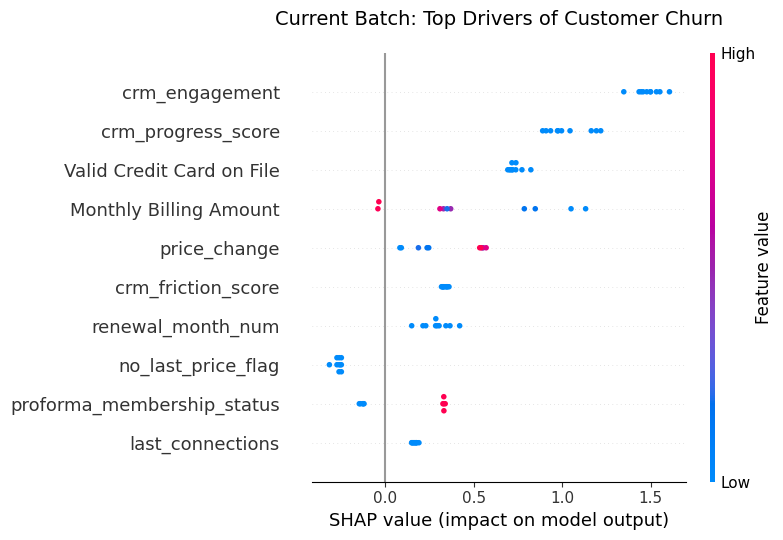

In [7]:
# Global SHAP Summary Plot (Optional, for all new predictions)
display_features = [friendly_names.get(col, col) for col in X_new.columns]
plt.figure(figsize=(10, 6))
plt.title("Current Batch: Top Drivers of Customer Churn", fontsize=14, pad=20)
shap.summary_plot(shap_values, X_new, feature_names=display_features, max_display=10)